
=== Processing 260610-07(HB)-A016.txt ===
Year =  2026.0
Month =  6.0
Day =  10.0
Latitude (degs N) =  34.24348
Longitude (degs E) =  -77.9698
Secchi depth (cm) =  101.0
Forel Ule =  99.0
pH =  99.0
260610-07(HB)-A016.txt: downcast window 52-96; no excluded interval
260610-07(HB)-A016.txt: upcast window 207-279; excluded interval 248-265


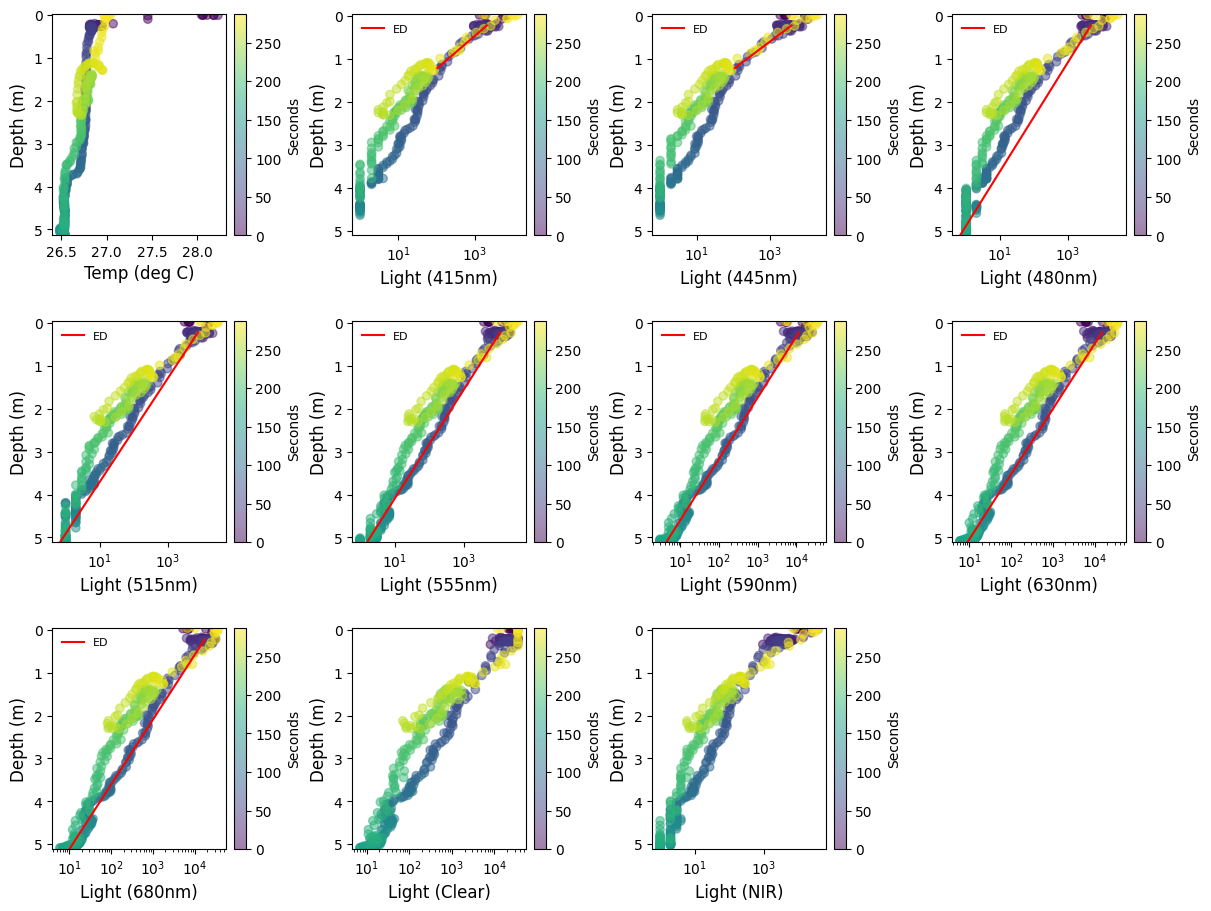

In [11]:
# src.beta
# Programs and functions
from calendar import Day, Month
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import datetime
import linecache
import re
from matplotlib import pyplot as plt
from pathlib import Path

from scipy.stats import linregress

# Datafiles
data_dir = Path.cwd().parent / "CFRE" / "Cruise 3"
files = [
    data_dir / "260610-07(HB)-A016.txt",
]

# Function to process a single SSD file
def process_file(filepath):
#Extract from file: Secchi Depth (SD), Forel–Ule (FU), 
#pH, serial number of device (SN), latitude, longitude and date
    # Turn Path object into a plain string for file readers.
    filepath_str = str(filepath)
    SD = linecache.getline(filepath_str, 1)
    SD = float(re.findall(r'\d+', SD)[0]) if re.findall(r'\d+', SD) else 0.0
    FU = linecache.getline(filepath_str, 2)
    FU = float(re.findall(r'\d+', FU)[0]) if re.findall(r'\d+', FU) else 0.0
    pH = linecache.getline(filepath_str, 3)
    pH = float(re.findall(r'\d+', pH)[0]) if re.findall(r'\d+', pH) else 0.0
    SN = linecache.getline(filepath_str, 4)
    SN = float(re.findall(r'\d+', SN)[0]) if re.findall(r'\d+', SN) else 0.0
    Latitude = linecache.getline(filepath_str, 5)
    Latitude = float(re.findall(r'-?\d+\.?\d+', Latitude)[0]) if re.findall(r'-?\d+\.?\d+', Latitude) else 0.0
    Longitude = linecache.getline(filepath_str, 6)
    Longitude = float(re.findall(r'-?\d+\.?\d+', Longitude)[0]) if re.findall(r'-?\d+\.?\d+', Longitude) else 0.0
    Date = linecache.getline(filepath_str, 7)
    Date = re.findall(r'\d+', Date)
    Year = float(Date[0]) if len(Date) > 0 else 0.0
    Month = float(Date[1]) if len(Date) > 1 else 0.0
    Day = float(Date[2]) if len(Date) > 2 else 0.0

    #Extract profile data
    df = pd.read_csv(filepath_str, header=7)
    Time_SS = df.loc[:,'Time (UTC)'].to_numpy()
    Pressure_SS = df.loc[:,' Pressure (mbar) MS5803'].to_numpy()
    Temp_MS5803_SS = df.loc[:,' Temp (deg C) MS5803'].to_numpy()
    E415nm_SS = df.loc[:,' ED 415nm'].to_numpy()
    E445nm_SS = df.loc[:,' ED 445nm'].to_numpy()
    E480nm_SS = df.loc[:,' ED 480nm'].to_numpy()
    E515nm_SS = df.loc[:,' ED 515nm'].to_numpy()
    E555nm_SS = df.loc[:,' ED 555nm'].to_numpy()
    E590nm_SS = df.loc[:,' ED 590nm'].to_numpy()
    E630nm_SS = df.loc[:,' ED 630nm'].to_numpy()
    E680nm_SS = df.loc[:,' ED 680nm'].to_numpy()
    EPAR_SS = df.loc[:,' ED Clear'].to_numpy()
    ENIR_SS = df.loc[:,' ED NIR'].to_numpy()
    Temp_TH_SS = df.loc[:,' Temp (deg C) TMP117'].to_numpy()
    
    #Compute atmospheric pressure assuming first 5 readings are in atmosphere
    ATMOS_P = np.median(Pressure_SS[0:5])

    #Correct differences in sensor distance
    #Compute depth (assuming pressure = depth)
    Depth_SS = ((Pressure_SS - ATMOS_P)/100.)
    #Correct for distance between temperature sensor and pressure sensor
    Depth_SS_T = Depth_SS + 0.007
    #Correct for distance between light sensor and pressure sensor
    Depth_SS_L = Depth_SS - 0.02
    
    #Sort time to decimal hour and compute seconds (DATA_SEC) and second since start (DATA_SEC0)
    HH = np.empty([len(Time_SS)])
    MM = np.empty([len(Time_SS)])
    SS = np.empty([len(Time_SS)])
    for j in range(len(Time_SS)):
        time = datetime.datetime.strptime(Time_SS[j], '%H:%M:%S')
        HH[j] = time.hour
        MM[j] = time.minute
        SS[j] = time.second
    # Convert each HH:MM:SS timestamp into elapsed seconds.
    DATA_SEC = (HH*3600.) + (MM*60.) + (SS)
    DATA_SEC0 = DATA_SEC - DATA_SEC[0]

    #Print extracted data
    print('Year = ', Year)
    print('Month = ', Month)
    print('Day = ', Day)
    print('Latitude (degs N) = ', Latitude)
    print('Longitude (degs E) = ', Longitude)
    print('Secchi depth (cm) = ', SD)
    print('Forel Ule = ', FU)
    print('pH = ', pH)
    
    # Return a dictionary containing all arrays needed by later plotting and fitting steps.
    return {
        # File identifier and environmental metadata (depth, color, pH, location, date)
        'filename': filepath.name, 'metadata': {'SD': SD, 'FU': FU, 'pH': pH, 'Latitude': Latitude, 'Longitude': Longitude, 'Year': Year, 'Month': Month, 'Day': Day},
        # Time and depth arrays: uncorrected (SS), temperature-corrected (T), light-corrected (L), and normalized time (0)
        'Time_SS': Time_SS, 'Depth_SS_T': Depth_SS_T, 'Depth_SS_L': Depth_SS_L, 'DATA_SEC0': DATA_SEC0,
        # Spectral irradiance arrays for 8 wavelengths (415–680 nm)
        'E415nm_SS': E415nm_SS, 'E445nm_SS': E445nm_SS, 'E480nm_SS': E480nm_SS, 'E515nm_SS': E515nm_SS,
        'E555nm_SS': E555nm_SS, 'E590nm_SS': E590nm_SS, 'E630nm_SS': E630nm_SS, 'E680nm_SS': E680nm_SS,
        # Broad-spectrum irradiance: PAR (photosynthetically active radiation) and NIR (near-infrared)
        'EPAR_SS': EPAR_SS, 'ENIR_SS': ENIR_SS, 'Temp_TH_SS': Temp_TH_SS
    }

# Process all SSD files
all_data = {}
for filepath in files:
    filename = filepath.name
    print(f"\n=== Processing {filename} ===")
    try:
        data = process_file(filepath)
        all_data[filename] = data
    except Exception as e:
        print(f"Error: {e}")

# Plot temperature and irradiance profiles for the first cast as reference
if len(all_data) > 0:
    # Select first file and create 3×4 subplot grid (12 panels for overview)
    first_file = list(all_data.keys())[0]
    data = all_data[first_file]
    fig, ([ax1, ax2, ax3, ax4], [ax5, ax6, ax7, ax8], [ax9, ax10, ax11, ax12]) = plt.subplots(3,4, figsize=(12,9), constrained_layout=True, gridspec_kw={'hspace': 0.1})

# These are the workbook columns used later for matching and cast-window selection.
# The two excluded columns describe an internal interval to leave out of the fit.
columns = [
    "Cruise_#", "Date", "Station", "SSD_ID", "Filename", "Start_time", "Conditions", "Notes",
    "start_idx_down", "end_idx_down", "start_idx_up", "end_idx_up",
    "excluded_start_idx", "excluded_end_idx",
]

"""
Extract and match metadata from SSD-Metadata.xlsx to the processed cast data.
"""

# Path to metadata workbook used for cast matching and window extraction
metadata_path = Path.cwd().parent / "SSD-Metadata.xlsx"

# Read metadata once and preserve every column so the selected row can be reused later.
try:
    metadata_df = pd.read_excel(metadata_path)
    metadata_all = metadata_df.copy()
except Exception as e:
    print(f"Error reading SSD-Metadata.xlsx: {e}")
    metadata_all = pd.DataFrame()


def to_yymmdd(val):
    """Normalize metadata dates to a clean string for filename matching."""
    if pd.isna(val):
        return None
    return str(val).strip()


def time_to_seconds(val):
    """Convert a metadata time value into seconds after midnight."""
    if pd.isna(val):
        return None
    if isinstance(val, pd.Timestamp):
        t = val.time()
        return t.hour * 3600 + t.minute * 60 + t.second
    if isinstance(val, datetime.time):
        return val.hour * 3600 + val.minute * 60 + val.second

    s = str(val).strip()
    try:
        t = datetime.datetime.strptime(s, '%H:%M:%S')
        return t.hour * 3600 + t.minute * 60 + t.second
    except ValueError:
        return None


def convert_window_value(val, cast_start_sec=None):
    """Convert either a sample index or clock time into a sample index."""
    if pd.isna(val):
        return None

    # Numeric metadata is already an index, so keep it as an integer.
    if isinstance(val, (int, float)) and np.isfinite(val):
        return (round(float(val)))

    if isinstance(val, pd.Timestamp):
        val = val.time()
    if isinstance(val, datetime.time):
        seconds = val.hour * 3600 + val.minute * 60 + val.second
        if cast_start_sec is None:
            return None
        return (round(seconds - cast_start_sec))

    s = str(val).strip()
    if not s:
        return None

    # Clock times are converted to elapsed samples relative to the first cast reading.
    if ':' in s:
        seconds = time_to_seconds(s)
        if seconds is None:
            return None
        if cast_start_sec is None:
            return None
        return (round(seconds - cast_start_sec))

    try:
        return (round(float(s)))
    except (TypeError, ValueError):
        return None


def match_txt_to_meta(filename):
    """Extract the station and date keys used to find the matching workbook row."""
    station_match = re.search(r"\(([^)]+)\)", filename)
    station = station_match.group(1) if station_match else None
    date = filename.split('-')[0]
    ssd_id_match = re.search(r"-([^-]+)\.txt$", filename)
    ssd_id = ssd_id_match.group(1) if ssd_id_match else None
    return station, date, ssd_id


if len(all_data) == 0:
    print("No cast data available to match against metadata.")
elif metadata_all.empty:
    print("Metadata table is empty; cannot match casts.")
else:
    # Check that the columns needed to identify the cast windows exist before processing rows.
    slice_data = {"Station", "Date", "start_idx_down", "end_idx_down", "start_idx_up", "end_idx_up"}
    missing = [c for c in slice_data if c not in metadata_all.columns]
    if missing:
        print(f"Metadata missing required columns: {missing}")
    else:
        metadata_view = metadata_all.copy()
        # Create normalized helper columns so station and date comparisons are consistent.
        metadata_view["_station"] = metadata_view["Station"].fillna("").astype(str).str.strip()
        metadata_view["_date"] = metadata_view["Date"].apply(to_yymmdd)

        for filename, data in all_data.items():
            station, date, ssd_id = match_txt_to_meta(filename)

            data["station"] = station
            data["date"] = date

            # Start with empty windows; each matching metadata row fills these below.
            data["down_window"] = None
            data["up_window"] = None

            if station is None or date is None:
                print(f"{filename}: could not parse station/date from filename")
                continue

            station_key = station.strip()
            date_key = date
            # Select metadata rows whose station and date match this file.
            matches = metadata_view[
                (metadata_view["_station"] == station_key) &
                (metadata_view["_date"] == date_key) &
                (metadata_view["SSD_ID"] == ssd_id)
]

            if matches.empty:
                print(f"{filename}: no matching metadata row for station={station}, date={date}")
                continue

            if len(matches) > 1:
                pass

            row = matches.iloc[0]
            # Keep the original metadata row and both direction-specific windows with the cast.
            data["metadata_window"] = {
                "row": row.to_dict(),
                "down": {"start": row["start_idx_down"], "end": row["end_idx_down"]},
                "up": {"start": row["start_idx_up"], "end": row["end_idx_up"]},
            }

            # Convert clock-based metadata values relative to the first sample in this cast.
            cast_start_sec = None
            if len(data["Time_SS"]) > 0:
                cast_start_sec = time_to_seconds(data["Time_SS"][0])

            # Read the optional excluded interval once and apply it to both cast directions.
            excluded_start = None
            excluded_end = None
            if "excluded_start_idx" in row.index and "excluded_end_idx" in row.index:
                excluded_start = convert_window_value(row["excluded_start_idx"], cast_start_sec)
                excluded_end = convert_window_value(row["excluded_end_idx"], cast_start_sec)
                if excluded_start is not None and excluded_end is not None:
                    # Ensure the interval is ordered before it is used as a slice.
                    if excluded_start > excluded_end:
                        excluded_start, excluded_end = excluded_end, excluded_start
                    n = len(data["Time_SS"])
                    # Keep exclusion indices inside the available sample array.
                    excluded_start = max(0, min(excluded_start, n - 1))
                    excluded_end = max(0, min(excluded_end, n - 1))

            for direction in ("down", "up"):
                # Each direction has its own included window from the metadata workbook.
                raw_start = row[f"start_idx_{direction}"]
                raw_end = row[f"end_idx_{direction}"]

                start_idx = convert_window_value(raw_start, cast_start_sec)
                end_idx = convert_window_value(raw_end, cast_start_sec)

                if start_idx is None or end_idx is None:
                    print(
                        f"{filename}: invalid {direction} window values "
                        f"start={raw_start}, end={raw_end}"
                    )
                    data[f"{direction}_window"] = None
                    continue

                n = len(data["Time_SS"])
                if n == 0:
                    print(f"{filename}: no profile samples available")
                    data[f"{direction}_window"] = None
                    continue

                # If start/end were reversed in the workbook, put them in ascending order.
                if start_idx > end_idx:
                    start_idx, end_idx = end_idx, start_idx

                # Keep the included-window indices inside the valid array bounds.
                start_idx = max(0, min(start_idx, n - 1))
                end_idx = max(0, min(end_idx, n - 1))

                # Start by selecting the complete metadata window.
                include_mask = np.zeros(n, dtype=bool)
                include_mask[start_idx:end_idx + 1] = True

                excluded_overlaps_window = (
                    excluded_start is not None
                    and excluded_end is not None
                    and excluded_start <= end_idx
                    and excluded_end >= start_idx
)

                if excluded_overlaps_window:
                    # Remove only the flagged interval; the plotted full profile remains unchanged.
                    excluded_mask = np.zeros(n, dtype=bool)
                    excluded_mask[excluded_start:excluded_end + 1] = True
                    include_mask[excluded_mask] = False

                # Convert the boolean selection into integer positions for array slicing.
                keep_idx = np.nonzero(include_mask)[0]
                if len(keep_idx) == 0:
                    if excluded_overlaps_window:
                        print(f"{filename}: {direction}cast window {start_idx}-{end_idx}; excluded interval {excluded_start}-{excluded_end} leaves no valid samples")
                    else:
                        print(f"{filename}: {direction}cast window {start_idx}-{end_idx}; no valid samples in selected window")
                    data[f"{direction}_window"] = None
                    continue

                # Slice every fitting array with the same positions so time, depth, and irradiance stay aligned.
                arrays = {
                    "time": data["Time_SS"][keep_idx],
                    "depth": data["Depth_SS_L"][keep_idx],
                    "temp": data["Temp_TH_SS"][keep_idx],
                    "E415nm": data["E415nm_SS"][keep_idx],
                    "E445nm": data["E445nm_SS"][keep_idx],
                    "E480nm": data["E480nm_SS"][keep_idx],
                    "E515nm": data["E515nm_SS"][keep_idx],
                    "E555nm": data["E555nm_SS"][keep_idx],
                    "E590nm": data["E590nm_SS"][keep_idx],
                    "E630nm": data["E630nm_SS"][keep_idx],
                    "E680nm": data["E680nm_SS"][keep_idx],
                    "EPAR": data["EPAR_SS"][keep_idx],
                    "ENIR": data["ENIR_SS"][keep_idx],
                }

                # Store both the original window boundaries and the exclusion boundaries for later fitting.
                data[f"{direction}_window"] = {
                    "start_idx": start_idx,
                    "end_idx": end_idx,
                    "excluded_start_idx": excluded_start,
                    "excluded_end_idx": excluded_end,
                    "arrays": arrays,
                }
                if excluded_overlaps_window:
                    print(f"{filename}: {direction}cast window {start_idx}-{end_idx}; excluded interval {excluded_start}-{excluded_end}")
                else:
                    print(f"{filename}: {direction}cast window {start_idx}-{end_idx}; no excluded interval")


def add_windowed_fit_line(ax, data, channel_key, color="red", label="ED"):
    # Collect valid points from the stored downcast and upcast fitting windows.
    depth_parts = []
    value_parts = []

    # Use both down and up windows, then combine valid points.
    for window_name in ("down_window", "up_window"):
        window = data.get(window_name)
        if window is None:
            continue
        arrays = window.get("arrays", {})
        if not arrays:
            continue

        depth_vals = np.asarray(arrays.get("depth", []), dtype=float)
        value_vals = np.asarray(arrays.get(channel_key, []), dtype=float)

        # Regression requires finite, non-negative depths and positive irradiance for log transformation.
        valid = (
            np.isfinite(depth_vals) &
            np.isfinite(value_vals) &
            (depth_vals >= 0) &
            (value_vals > 0)
        )

        if np.sum(valid) > 10:
            depth_parts.append(depth_vals[valid])
            value_parts.append(value_vals[valid])

    # Do not attempt a regression if neither window contains enough valid points.
    if not depth_parts:
        return None

    depth_fit = np.concatenate(depth_parts)
    value_fit = np.concatenate(value_parts)

    # Use the shallowest selected point as the surface reference E0.
    surface_idx = np.argmin(depth_fit)
    e0 = value_fit[surface_idx]
    ln_e = np.log(value_fit / e0)

    # Fit a straight line in log space: ln(E/E0) vs depth.
    slope, intercept, _, _, _ = linregress(depth_fit, ln_e)
    depth_range = np.linspace(np.min(depth_fit), np.max(depth_fit), 80)
    fit_x = e0 * np.exp(intercept + slope * depth_range)

    # Plot the fitted irradiance values against the same depth range as the regression.
    ax.plot(fit_x, depth_range, color=color, linewidth=1.5, label=label)
    return ax

# Panel 1: Temperature profile (from TMP117 thermistor)
im1 = ax1.scatter(data['Temp_TH_SS'], data['Depth_SS_T'], c=data['DATA_SEC0'], marker='o', alpha=0.5)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_xlabel('Temp (deg C)', fontsize=12)
ax1.set_ylim([np.max(data['Depth_SS_T']),np.min(data['Depth_SS_T'])])
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Seconds")

# Panels 2–11: Spectral irradiance profiles (8 wavelengths + PAR + NIR)
irr_list = [(data['E415nm_SS'], 'Light (415nm)', ax2), 
            (data['E445nm_SS'], 'Light (445nm)', ax3),
            (data['E480nm_SS'], 'Light (480nm)', ax4), 
            (data['E515nm_SS'], 'Light (515nm)', ax5),
            (data['E555nm_SS'], 'Light (555nm)', ax6), 
            (data['E590nm_SS'], 'Light (590nm)', ax7),
            (data['E630nm_SS'], 'Light (630nm)', ax8), 
            (data['E680nm_SS'], 'Light (680nm)', ax9),
            (data['EPAR_SS'], 'Light (Clear)', ax10), 
            (data['ENIR_SS'], 'Light (NIR)', ax11)]

fit_channel_map = {
    'Light (415nm)': 'E415nm',
    'Light (445nm)': 'E445nm',
    'Light (480nm)': 'E480nm',
    'Light (515nm)': 'E515nm',
    'Light (555nm)': 'E555nm',
    'Light (590nm)': 'E590nm',
    'Light (630nm)': 'E630nm',
    'Light (680nm)': 'E680nm',
}

for E_data, label, ax in irr_list:
    im = ax.scatter(E_data, data['Depth_SS_L'], c=data['DATA_SEC0'], marker='o', alpha=0.5)
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylim([np.max(data['Depth_SS_L']), np.min(data['Depth_SS_L'])])
    ax.set_xscale('log')  # Log scale reveals exponential decay with depth
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Seconds")

    if label in fit_channel_map:
        # Add the fit calculated from the selected metadata windows, not the full scatter profile.
        add_windowed_fit_line(ax, data, fit_channel_map[label], color='red', label='ED')
        ax.legend(loc='upper left', frameon=False, fontsize=8)

# Panel 12: Hidden (placeholder for 3×4 grid)
ax12.set_visible(False)

In [12]:
columns = [
    "Cruise_#", "Date", "Start_time", "SSD_ID", "Station", "Conditions", "Notes",
    "start_idx_down", "end_idx_down", "start_idx_up", "end_idx_up",
]

# Path to metadata workbook used for cast matching and window extraction
metadata_path = Path.cwd().parent / "SSD-Metadata.xlsx"

# Read metadata once and preserve every column.
try:
    metadata_df = pd.read_excel(metadata_path)
    metadata_all = metadata_df.copy()
except Exception as e:
    print(f"Error reading SSD-Metadata.xlsx: {e}")
    metadata_all = pd.DataFrame()


def to_yymmdd(val):
    """
    Normalize metadata dates to a clean string.
    """
    if pd.isna(val):
        return None
    return str(val).strip()


def time_to_seconds(val):
    """
    Convert HH:MM:SS values to seconds.
    """
    if pd.isna(val):
        return None
    if isinstance(val, pd.Timestamp):
        t = val.time()
        return t.hour * 3600 + t.minute * 60 + t.second
    if isinstance(val, datetime.time):
        return val.hour * 3600 + val.minute * 60 + val.second

    s = str(val).strip()
    try:
        t = datetime.datetime.strptime(s, '%H:%M:%S')
        return t.hour * 3600 + t.minute * 60 + t.second
    except ValueError:
        return None


def convert_window_value(val, cast_start_sec=None):
    """
    Convert a metadata window value into a sample index.
    Time-like values are converted relative to the cast start.
    Numeric values are used directly as indices.
    """
    if pd.isna(val):
        return None

    if isinstance(val, (int, float)) and np.isfinite(val):
        return (round(float(val)))

    if isinstance(val, pd.Timestamp):
        val = val.time()
    if isinstance(val, datetime.time):
        seconds = val.hour * 3600 + val.minute * 60 + val.second
        if cast_start_sec is None:
            return None
        return (round(seconds - cast_start_sec))

    s = str(val).strip()
    if not s:
        return None

    if ':' in s:
        seconds = time_to_seconds(s)
        if seconds is None:
            return None
        if cast_start_sec is None:
            return None
        return (round(seconds - cast_start_sec))

    try:
        return (round(float(s)))
    except (TypeError, ValueError):
        return None


def match_txt_to_meta(filename):
    """
    Parse filename for metadata keys used in matching.
    """
    station_match = re.search(r"\(([^)]+)\)", filename)
    station = station_match.group(1) if station_match else None
    date = filename.split('-')[0]
    return station, date


if len(all_data) == 0:
    print("No cast data available to match against metadata.")
elif metadata_all.empty:
    print("Metadata table is empty; cannot match casts.")
else:
    # Required columns for matching
    slice_data = {"Station", "Date", "start_idx_down", "end_idx_down", "start_idx_up", "end_idx_up"}
    missing = [c for c in slice_data if c not in metadata_all.columns]
    if missing:
        print(f"Metadata missing required columns: {missing}")
    else:
        metadata_view = metadata_all.copy()
        metadata_view["_station"] = metadata_view["Station"].fillna("").astype(str).str.strip()
        metadata_view["_date"] = metadata_view["Date"].apply(to_yymmdd)

        for filename, data in all_data.items():
            station, date = match_txt_to_meta(filename)

            data["station"] = station
            data["date"] = date

            data["down_window"] = None
            data["up_window"] = None

            if station is None or date is None:
                print(f"{filename}: could not parse station/date from filename")
                continue

            station_key = station.strip()
            date_key = date
            matches = metadata_view[
                metadata_view["_station"].eq(station_key) &
                metadata_view["_date"].eq(date_key)
            ]

            if matches.empty:
                print(f"{filename}: no matching metadata row for station={station}, date={date}")
                continue

            if len(matches) > 1:
                print(f"{filename}: multiple metadata rows found ({len(matches)}); using first match")

            row = matches.iloc[0]
            data["metadata_window"] = {
                "row": row.to_dict(),
                "down": {"start": row["start_idx_down"], "end": row["end_idx_down"]},
                "up": {"start": row["start_idx_up"], "end": row["end_idx_up"]},
            }

            cast_start_sec = None
            if len(data["Time_SS"]) > 0:
                cast_start_sec = time_to_seconds(data["Time_SS"][0])

            for direction in ("down", "up"):
                raw_start = row[f"start_idx_{direction}"]
                raw_end = row[f"end_idx_{direction}"]

                start_idx = convert_window_value(raw_start, cast_start_sec)
                end_idx = convert_window_value(raw_end, cast_start_sec)

                if start_idx is None or end_idx is None:
                    print(
                        f"{filename}: invalid {direction} window values "
                        f"start={raw_start}, end={raw_end}"
                    )
                    data[f"{direction}_window"] = None
                    continue

                n = len(data["Time_SS"])
                if n == 0:
                    print(f"{filename}: no profile samples available")
                    data[f"{direction}_window"] = None
                    continue

                if start_idx > end_idx:
                    start_idx, end_idx = end_idx, start_idx

                start_idx = max(0, min(start_idx, n - 1))
                end_idx = max(0, min(end_idx, n - 1))

                arrays = {
                    "time": data["Time_SS"][start_idx:end_idx + 1],
                    "depth": data["Depth_SS_L"][start_idx:end_idx + 1],
                    "temp": data["Temp_TH_SS"][start_idx:end_idx + 1],
                    "E415nm": data["E415nm_SS"][start_idx:end_idx + 1],
                    "E445nm": data["E445nm_SS"][start_idx:end_idx + 1],
                    "E480nm": data["E480nm_SS"][start_idx:end_idx + 1],
                    "E515nm": data["E515nm_SS"][start_idx:end_idx + 1],
                    "E555nm": data["E555nm_SS"][start_idx:end_idx + 1],
                    "E590nm": data["E590nm_SS"][start_idx:end_idx + 1],
                    "E630nm": data["E630nm_SS"][start_idx:end_idx + 1],
                    "E680nm": data["E680nm_SS"][start_idx:end_idx + 1],
                    "EPAR": data["EPAR_SS"][start_idx:end_idx + 1],
                    "ENIR": data["ENIR_SS"][start_idx:end_idx + 1],
                }

                data[f"{direction}_window"] = {
                    "start_idx": start_idx,
                    "end_idx": end_idx,
                    "arrays": arrays,
                }

                print(f"{filename}: {direction}cast window {start_idx}-{end_idx}")


260610-07(HB)-A016.txt: downcast window 52-96
260610-07(HB)-A016.txt: upcast window 207-279


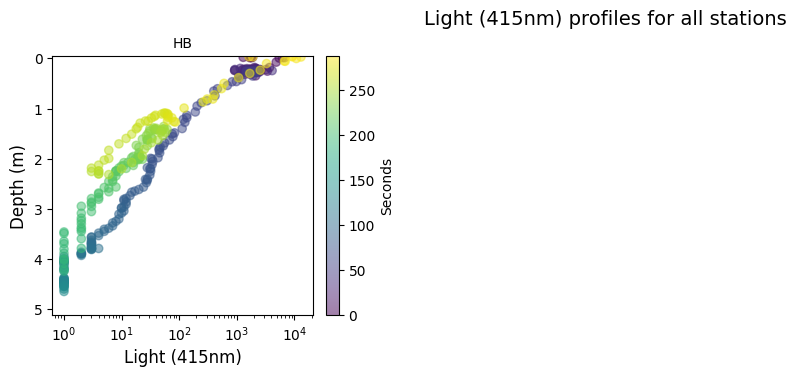

In [13]:
# 415nm panels for all stations 
if len(all_data) > 0:
    # preserve the original cast order from the loaded files
    ordered = list(all_data.keys())

    num = len(ordered)

    # Use fixed 3x4 rectangular layout to match script 1
    nrows, ncols = 3, 4

    # use the deepest cast depth as the shared y-range for all stations
    # this makes every subplot comparable on the same vertical scale
    global_min_depth = min(np.min(data['Depth_SS_L']) for data in all_data.values())
    global_max_depth = max(np.max(data['Depth_SS_L']) for data in all_data.values())

    # create a grid of subplot axes
    fig, axs = plt.subplots(nrows, ncols, figsize=(12, 9), constrained_layout=True, sharey=False)
    axs = np.array(axs).reshape(-1)

    # Plot as many stations as we have room for (up to 12 panels)
    max_panels = nrows * ncols
    for idx, fn in enumerate(ordered[:max_panels]):
        data = all_data[fn]
        ax = axs[idx]

        # plot each cast in the preferred order
        im = ax.scatter(data['E415nm_SS'], data['Depth_SS_L'], c=data['DATA_SEC0'], marker='o', alpha=0.5)

        # extract station label from the filename
        mobj = re.search(r"\(([^)]+)\)", fn)
        station = mobj.group(1) if mobj else fn
        ax.set_title(station, fontsize=10)
        ax.set_xlabel('Light (415nm)', fontsize=12)
        ax.set_ylabel('Depth (m)', fontsize=12)
        ax.set_xscale('log')

        # use the same depth limits for every subplot so the y-axis is consistent
        ax.set_ylim([global_max_depth, global_min_depth])
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label('Seconds')

    # hide any unused subplot axes in the grid
    for ax in axs[num:max_panels]:
        ax.set_visible(False)

    if num > max_panels:
        print(f"Showing first {max_panels} stations out of {num} total.")

    fig.suptitle('Light (415nm) profiles for all stations', fontsize=14)
    plt.show()
else:
    print("No data available to plot 415nm profiles.")

In [14]:
# Kd analysis: Helper functions for spectral diffuse attenuation coefficient


def compute_kd_for_wavelength(E_data, depth_data, window=None):
    """
    Core Kd computation for a single irradiance array.
    Filters valid data, normalizes by surface irradiance, and fits ln(E/E0) = -Kd*depth.
    Returns: (Kd_value, R_squared) or (None, None) if insufficient valid data
    """
    # Filter: positive irradiance, valid finite numbers, depth ≥ 0
    valid_idx = (E_data > 0) & np.isfinite(E_data) & (depth_data >= 0)

    # Restrict the fit to the metadata-defined cast window when it is available.
    if window is not None:
        start_idx = window.get("start_idx")
        if start_idx is None:
            start_idx = window.get("start")
        end_idx = window.get("end_idx")
        if end_idx is None:
            end_idx = window.get("end")
        if start_idx is not None and end_idx is not None:
            window_mask = np.zeros(len(E_data), dtype=bool)
            window_mask[start_idx:end_idx + 1] = True
            valid_idx = valid_idx & window_mask

    # Only regress if there are sufficient valid samples (>10 points)
    if np.sum(valid_idx) > 10:
        # Keep the normalization and regression on the same windowed subset.
        depth_window = depth_data[valid_idx]
        E_window = E_data[valid_idx]

        # Normalize by the shallowest point within the selected window.
        surface_idx = np.argmin(depth_window)
        E0 = E_window[surface_idx]
        ln_E = np.log(E_window / E0)

        # Fit: ln(E/E0) = -Kd * depth  =>  slope = -Kd
        slope, _, r_value, _, _ = linregress(depth_window, ln_E)
        return -slope, r_value**2

    return None, None


def compute_kd_spectrum(data):
    """
    Compute Kd spectrum for all spectral bands using the matched cast window when available.
    """
    window = None
    if data.get("down_window") is not None:
        window = data["down_window"]
    elif data.get("up_window") is not None:
        window = data["up_window"]

    # Pair each irradiance array with its nominal wavelength
    irradiance_data = [
        (data['E415nm_SS'], 415),
        (data['E445nm_SS'], 445),
        (data['E480nm_SS'], 480),
        (data['E515nm_SS'], 515),
        (data['E555nm_SS'], 555),
        (data['E590nm_SS'], 590),
        (data['E630nm_SS'], 630),
        (data['E680nm_SS'], 680),
    ]
    Kd_values, wavelengths_Kd, R_squared = [], [], []

    for E_data, wl in irradiance_data:
        kd, r2 = compute_kd_for_wavelength(E_data, data['Depth_SS_L'], window=window)
        if kd is not None:
            Kd_values.append(kd)
            wavelengths_Kd.append(wl)
            R_squared.append(r2)

    return Kd_values, wavelengths_Kd, R_squared


# def compute_kd_at_wavelength(data, target_wl):
#     """
#     Compute Kd at a single target wavelength.
#     Returns: (Kd_value, R_squared) or (None, None) if wavelength not available or insufficient data
#     """
#     # Map wavelength to irradiance array
#     irradiance_map = {
#         415: data['E415nm_SS'],
#         445: data['E445nm_SS'],
#         480: data['E480nm_SS'],
#         515: data['E515nm_SS'],
#         555: data['E555nm_SS'],
#         590: data['E590nm_SS'],
#         630: data['E630nm_SS'],
#         680: data['E680nm_SS'],
#     }

    
#     if E_data is None:#     return compute_kd_for_wavelength(E_data, data['Depth_SS_L'])

#     E_data = irradiance_map.get(target_wl)
#         return None, None    

#     if E_data is None:
    #     return compute_kd_for_wavelength(E_data, data['Depth_SS_L'])
#         return None, None


260610-07(HB)-A016.txt:
  Windowed fit (metadata window):
    Kd(415 nm) = 2.993 m^-1  (R² = 0.917)
    Kd(445 nm) = 3.600 m^-1  (R² = 0.926)
    Kd(480 nm) = 3.368 m^-1  (R² = 0.917)
    Kd(515 nm) = 2.919 m^-1  (R² = 0.885)
    Kd(555 nm) = 2.536 m^-1  (R² = 0.866)
    Kd(590 nm) = 2.275 m^-1  (R² = 0.852)
    Kd(630 nm) = 2.263 m^-1  (R² = 0.835)
    Kd(680 nm) = 2.283 m^-1  (R² = 0.837)
  Full-profile fit (no window):
    Kd(415 nm) = 1.854 m^-1  (R² = 0.899)
    Kd(445 nm) = 1.998 m^-1  (R² = 0.881)
    Kd(480 nm) = 1.777 m^-1  (R² = 0.889)
    Kd(515 nm) = 1.910 m^-1  (R² = 0.926)
    Kd(555 nm) = 1.755 m^-1  (R² = 0.946)
    Kd(590 nm) = 1.566 m^-1  (R² = 0.940)
    Kd(630 nm) = 1.460 m^-1  (R² = 0.929)
    Kd(680 nm) = 1.467 m^-1  (R² = 0.928)


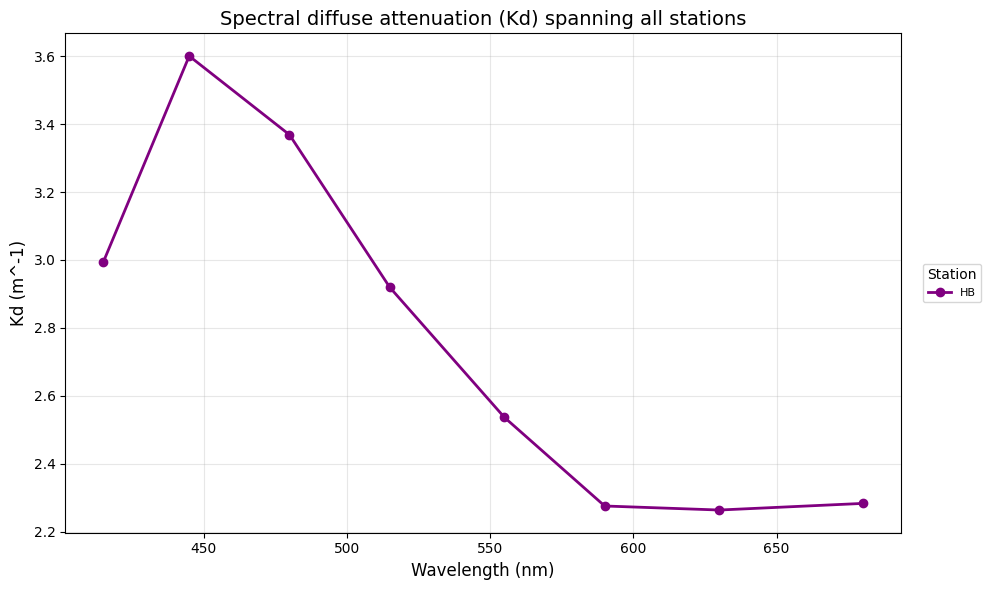

In [15]:
# Compare Kd spectra from all casts
if len(all_data) > 0:
    plt.figure(figsize=(10, 6))
    
    # Create a custom colormap gradient: purple → yellow → green
    from matplotlib.colors import LinearSegmentedColormap
    colors_list = ['purple', 'yellow', 'green']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('purple_yellow_green', colors_list, N=n_bins)
    
    # Get number of files to normalize the color gradient
    num_files = len(all_data)
    
    for idx, (filename, data) in enumerate(all_data.items()):
        Kd_values, wavelengths_Kd, R_squared = compute_kd_spectrum(data)
        if len(wavelengths_Kd) > 0:
            # Sort by wavelength
            sorted_idx = np.argsort(wavelengths_Kd)
            wl_sorted = np.array(wavelengths_Kd)[sorted_idx]
            kd_sorted = np.array(Kd_values)[sorted_idx]
            
            # Map day index to color gradient (0 to 1)
            color_pos = idx / (num_files - 1) if num_files > 1 else 0
            color = cmap(color_pos)
            
            # Extract station name from filename
            mobj = re.search(r"\(([^)]+)\)", filename)
            station = mobj.group(1) if mobj else filename
            plt.plot(wl_sorted, kd_sorted, 'o-', color=color, label=station, linewidth=2)
            
            # Print windowed-fit results
            print(f"\n{filename}:")
            print("  Windowed fit (metadata window):")
            for wl, kd, r2 in zip(wavelengths_Kd, Kd_values, R_squared):
                print(f"    Kd({wl:3d} nm) = {kd:.3f} m^-1  (R² = {r2:.3f})")

            # Print full-profile fit (for comparison)
            print("  Full-profile fit (no window):")
            for wl in wavelengths_Kd:
                E_data = data[f"E{wl}nm_SS"]
                kd_full, r2_full = compute_kd_for_wavelength(E_data, data['Depth_SS_L'])
                if kd_full is not None:
                    print(f"    Kd({wl:3d} nm) = {kd_full:.3f} m^-1  (R² = {r2_full:.3f})")
    
    plt.xlabel('Wavelength (nm)', fontsize=12)
    plt.ylabel('Kd (m^-1)', fontsize=12)
    plt.title('Spectral diffuse attenuation (Kd) spanning all stations', fontsize=14)
    plt.legend(fontsize=8, title='Station', title_fontsize=10, loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
